In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

df = pd.read_csv('D:\BankLoanRisk-Intelligence\Dataset\loans_clean.csv', parse_dates=['issue_d', 'last_pymnt_d'])
print(df.shape)
df.head()

(150000, 34)


C:\Users\praso\AppData\Local\Temp\ipykernel_18484\1804894240.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('D:\BankLoanRisk-Intelligence\Dataset\loans_clean.csv', parse_dates=['issue_d', 'last_pymnt_d'])


,id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,revol_bal,revol_util,total_acc,out_prncp,total_pymnt,last_pymnt_d,last_pymnt_amnt,defaulted,vintage_month,term_months,monthly_income,bureau_score
0,46164551,15000.0,60 months,17.57,377.41,D,D4,Registered Nurse,1 year,MORTGAGE,60000.0,Verified,2015-04-01,Charged Off,debt_consolidation,PA,31.18,0.0,695.0,699.0,1.0,23.0,10404.0,44.0,27.0,0.0,11685.070000,2017-11-01,377.41,1,2015-04,60.0,5000.000000,697.0
1,65757119,7000.0,36 months,14.33,240.37,C,C5,steward,10+ years,RENT,37000.0,Verified,2015-12-01,Fully Paid,debt_consolidation,IL,38.99,0.0,670.0,674.0,0.0,20.0,15957.0,80.0,26.0,0.0,7507.480000,2016-06-01,6316.78,0,2015-12,36.0,3083.333333,672.0
2,38529136,22000.0,36 months,12.69,737.99,C,C2,COO,10+ years,MORTGAGE,110000.0,Verified,2015-02-01,Fully Paid,major_purchase,CA,18.98,0.0,685.0,689.0,1.0,27.0,37499.0,40.4,70.0,0.0,24921.820003,2016-05-01,14628.74,0,2015-02,36.0,9166.666667,687.0
3,46407945,6000.0,36 months,7.89,187.72,A,A5,booth renter,< 1 year,RENT,40000.0,Source Verified,2015-04-01,Charged Off,debt_consolidation,MS,28.34,0.0,710.0,714.0,1.0,9.0,7474.0,58.9,20.0,0.0,5121.400000,2017-06-01,187.72,1,2015-04,36.0,3333.333333,712.0
4,60961966,1200.0,36 months,12.69,40.26,C,C2,eBay Manager,1 year,RENT,32000.0,Not Verified,2015-09-01,Fully Paid,debt_consolidation,CO,30.83,0.0,705.0,709.0,1.0,11.0,18858.0,68.3,30.0,0.0,1266.290000,2016-03-01,1106.94,0,2015-09,36.0,2666.666667,707.0


In [3]:
# Duplicate loan ids?
print('Duplicate ids:', df['id'].duplicated().sum())

# Target balance
print('\nDefault rate:', df['defaulted'].mean().round(4))
print(df['defaulted'].value_counts())

# Term should only be 36 or 60
print('\nTerm values:', df['term_months'].unique())

# Any non-positive loan amounts or incomes slipped through?
print('\nloan_amnt <= 0:', (df['loan_amnt'] <= 0).sum())
print('monthly_income <= 0:', (df['monthly_income'] <= 0).sum())

Duplicate ids: 0

Default rate: 0.2155
defaulted
0    117681
1     32319
Name: count, dtype: int64

Term values: [60. 36.]

loan_amnt <= 0: 0
monthly_income <= 0: 0


In [4]:
missing_pymnt_date = df[df['last_pymnt_d'].isna()]
print('Rows missing last_pymnt_d:', len(missing_pymnt_date))
print('Default rate among them:', missing_pymnt_date['defaulted'].mean().round(4))
print('(compare to overall default rate: 0.2155 — if much higher, confirms the early-default hypothesis)')

# emp_title: too high-cardinality to use directly. Drop it for modeling; keep emp_length instead.
print('\nUnique emp_title values:', df['emp_title'].nunique())

Rows missing last_pymnt_d: 345
Default rate among them: 1.0
(compare to overall default rate: 0.2155 — if much higher, confirms the early-default hypothesis)

Unique emp_title values: 51796


In [5]:
# Decision: drop emp_title from the modeling feature set (document this in data_quality_notes.md).
# Keep it in df for now in case you want it for a qualitative look later; just exclude it downstream.
model_features_note = "emp_title dropped: high-cardinality free text, not usable as a WOE bin without heavy NLP work that's out of scope here."
print(model_features_note)

emp_title dropped: high-cardinality free text, not usable as a WOE bin without heavy NLP work that's out of scope here.


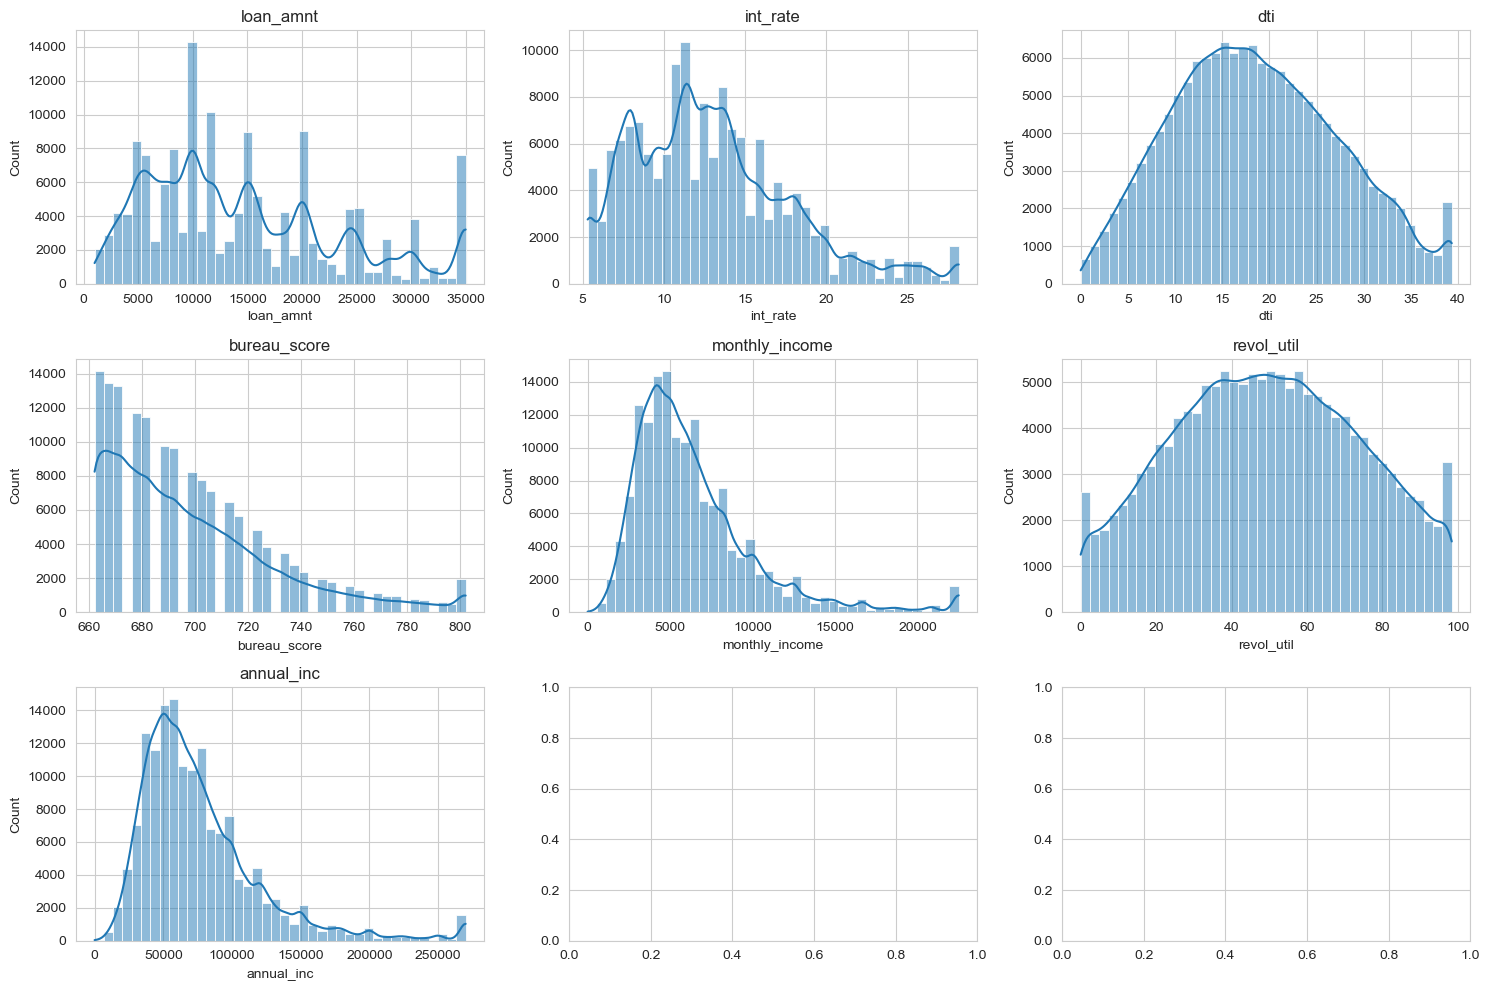

In [6]:
num_cols = ['loan_amnt', 'int_rate', 'dti', 'bureau_score', 'monthly_income', 'revol_util', 'annual_inc']
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, num_cols):
    data = df[col].clip(upper=df[col].quantile(0.99))  # clip extreme tail for readability only
    sns.histplot(data, bins=40, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [7]:
grade_summary = df.groupby('grade').agg(
    loans=('id', 'count'),
    avg_int_rate=('int_rate', 'mean'),
    default_rate=('defaulted', 'mean')
).sort_index()
grade_summary

,loans,avg_int_rate,default_rate
grade,,,
A,27114,6.923777,0.061075
B,43486,10.242168,0.144690
C,43475,13.731303,0.243841
D,21560,17.797759,0.337430
E,10145,21.437850,0.425333
F,3209,25.749854,0.510128
G,1011,29.033947,0.537092


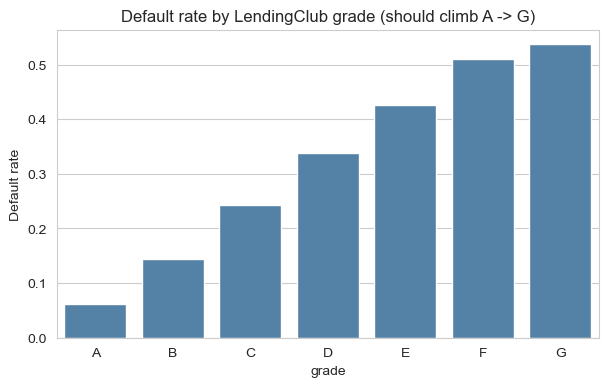

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=grade_summary.index, y=grade_summary['default_rate'], ax=ax, color='steelblue')
ax.set_ylabel('Default rate')
ax.set_title('Default rate by LendingClub grade (should climb A -> G)')
plt.show()

In [9]:
corr_cols = num_cols + ['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'defaulted']
corr = df[corr_cols].corr(numeric_only=True)['defaulted'].sort_values(key=abs, ascending=False)
corr

defaulted         1.000000
int_rate          0.282393
bureau_score     -0.138755
dti               0.081974
inq_last_6mths    0.081210
revol_util        0.070978
loan_amnt         0.065871
annual_inc       -0.038327
monthly_income   -0.038327
open_acc          0.023873
delinq_2yrs       0.019223
total_acc        -0.016658
Name: defaulted, dtype: float64

In [11]:
model_feature_cols = [
    'id', 'issue_d', 'vintage_month', 'loan_amnt', 'term_months', 'int_rate',
    'grade', 'sub_grade', 'purpose', 'emp_length', 'home_ownership',
    'monthly_income', 'dti', 'bureau_score', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'revol_util', 'total_acc', 'addr_state', 'defaulted'
]
df[model_feature_cols].to_csv(r"D:\BankLoanRisk-Intelligence\Dataset\loans_model_ready.csv", index=False)
print("Saved loans_model_ready.csv —", df[model_feature_cols].shape)

Saved loans_model_ready.csv — (150000, 21)
